In [1]:
# LAYER 1: Imports
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [2]:
# LAYER 2: Load Iris dataset
X, y = load_iris(return_X_y=True)

# Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (105, 4)
Test shape: (45, 4)


In [3]:
# LAYER 3: Decision Tree depths
depths = [1, 2, 3]

print("Decision Tree Results:")
for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc = accuracy_score(y_test, model.predict(X_test))

    print(f"Depth={d}: Train={train_acc:.3f}, Test={test_acc:.3f}")

Decision Tree Results:
Depth=1: Train=0.667, Test=0.667
Depth=2: Train=0.971, Test=0.889
Depth=3: Train=0.981, Test=0.978


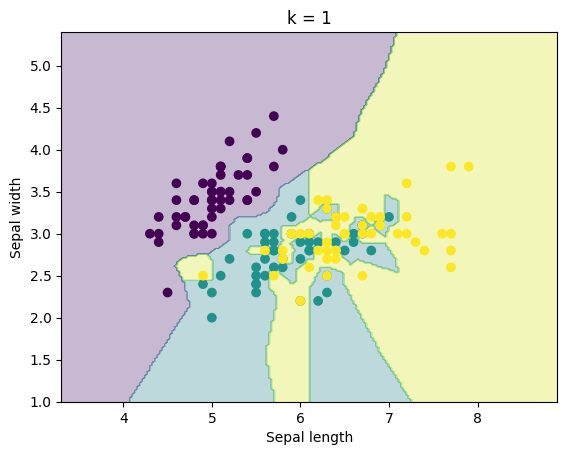

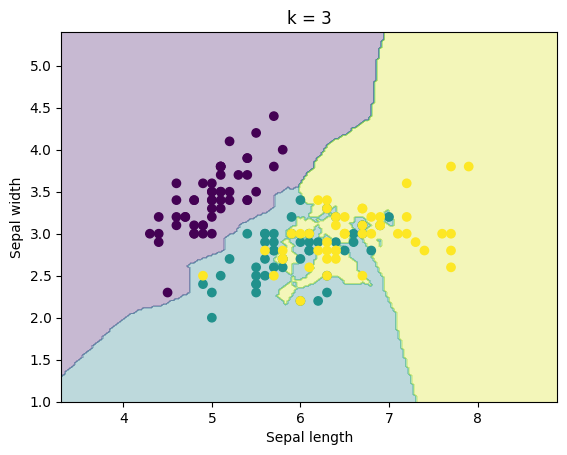

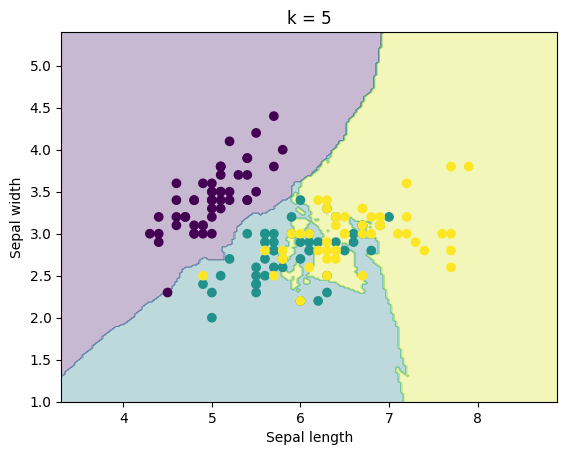

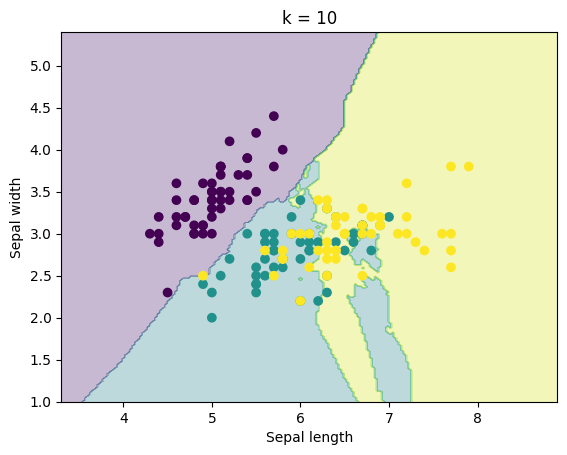

In [4]:
# LAYER 4: kNN boundaries using only 2 features
iris = load_iris()
X2 = iris.data[:, :2]   # sepal length & width
y2 = iris.target

ks = [1, 3, 5, 10]

for k in ks:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X2, y2)

    x_min, x_max = X2[:,0].min()-1, X2[:,0].max()+1
    y_min, y_max = X2[:,1].min()-1, X2[:,1].max()+1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure()
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X2[:,0], X2[:,1], c=y2)
    plt.title(f"k = {k}")
    plt.xlabel("Sepal length")
    plt.ylabel("Sepal width")
    plt.show()

In [5]:
# LAYER 5: Train kNN (k=5)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Confusion Matrix:
 [[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      1.00      0.97        15
           2       1.00      0.93      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



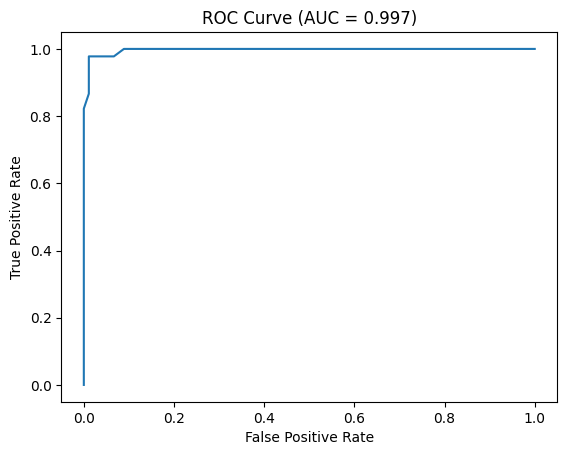

AUC: 0.9967901234567901


In [6]:
# LAYER 6: ROC Curve (multiclass)

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve (AUC = {roc_auc:.3f})")
plt.show()

print("AUC:", roc_auc)